In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import LabelEncoder
from data_load_utils import load_image, load_data, create_data_frame

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms

## Loading the Data

In [2]:
training_dir = "./data/train"
testing_dir = "./data/test"

In [6]:
emotions, images = load_data(training_dir)
le = LabelEncoder()
labels = le.fit_transform(emotions)

In [22]:
training_data = create_data_frame(emotions, labels, images)

In [8]:
test_emotions, test_images = load_data(testing_dir)
test_labels = le.transform(test_emotions)

In [9]:
testing_data = create_data_frame(test_emotions, test_labels, test_images)

## Preparing Data for CNN Model

In [122]:
X_train = np.stack(training_data["image"].values)
y_train = training_data["label"].values

In [123]:
X_test = np.stack(testing_data["image"].values)
y_test = testing_data["label"].values

In [124]:
transform = transforms.ToTensor()

In [125]:
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)/255
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

In [126]:
X_train_tensor = X_train_tensor.unsqueeze(1) 

In [127]:
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)/255
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

In [128]:
X_test_tensor = X_test_tensor.unsqueeze(1) 

In [129]:
training_data_tensor = TensorDataset(X_train_tensor, y_train_tensor)

In [130]:
testing_data_tensor = TensorDataset(X_test_tensor, y_test_tensor)

In [131]:
training_loader = DataLoader(training_data_tensor, 10, shuffle = True)

In [132]:
testing_loader = DataLoader(testing_data_tensor, 10, shuffle = False)

## Creating Custom CNN

In [133]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1, padding = 1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, 1, padding = 1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, 1, padding = 1)
        self.bn3 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(64*12*12, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 8)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.bn3(self.conv3(x)))

        x = x.view(-1, 64*12*12)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

## Training CNN

In [134]:
model = Model()

In [135]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [136]:
losses = []
scores = {}

In [152]:
import time
epochs = 5
start_time = time.time()

for epoch in range(epochs):
    model.train()
    corrects = 0
    wrongs = 0
    running_loss = 0

    for b, (X_train, y_train) in enumerate(training_loader):
        
        batch = b+1
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        predicted = torch.argmax(y_pred, dim=1)
        
        corrects += (predicted == y_train).sum().item()
        wrongs += (predicted != y_train).sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        if b % 1400 == 0:
            print(f"Epoch: {epoch}/{epochs}, Batch: {batch}. Current loss {running_loss/batch}")
    
    scores[epoch] = {
        "corrects": corrects,
        "wrongs": wrongs,
        "accuracy": corrects/(wrongs + corrects),
        "loss": running_loss/batch
    }
    print(f"Epoch: {epoch}. Current accuracy: {corrects/(corrects + wrongs)}")
    losses.append(running_loss/batch)

end_time = time.time()
time_total = (end_time - start_time)/60

print(f"Training took {time_total} minutes")

Epoch: 0/5, Batch: 1. Current loss 0.4000292420387268
Epoch: 0/5, Batch: 1401. Current loss 0.5346660703393384
Epoch: 0/5, Batch: 2801. Current loss 0.5498451452164637
Epoch: 0. Current accuracy: 0.8012469957156293
Epoch: 1/5, Batch: 1. Current loss 0.4842323660850525
Epoch: 1/5, Batch: 1401. Current loss 0.5283527375171646
Epoch: 1/5, Batch: 2801. Current loss 0.5312517626352026
Epoch: 1. Current accuracy: 0.8065066703821101
Epoch: 2/5, Batch: 1. Current loss 0.2848067283630371
Epoch: 2/5, Batch: 1401. Current loss 0.5179919544886599
Epoch: 2/5, Batch: 2801. Current loss 0.5210336747661403
Epoch: 2. Current accuracy: 0.8101292277682957
Epoch: 3/5, Batch: 1. Current loss 0.25033074617385864
Epoch: 3/5, Batch: 1401. Current loss 0.5248512088600015
Epoch: 3/5, Batch: 2801. Current loss 0.5254886108216181
Epoch: 3. Current accuracy: 0.8054965341878854
Epoch: 4/5, Batch: 1. Current loss 0.644904613494873
Epoch: 4/5, Batch: 1401. Current loss 0.5077761472379828
Epoch: 4/5, Batch: 2801. Curr

In [154]:
#Saving Model
torch.save(model, "./models/cnn_full_model.pth")

In [155]:
#Saving Model Params in order to make continued training possible
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
}, "./models/cnn_checkpoint.pth")

In [156]:
#Saving Scores Dict in order to keep track of model improvements in case of continued training
with open("./models/cnn_scores.pkl", "wb") as f:
    pickle.dump(scores, f)

In [158]:
accuracies = []

In [174]:
for value in scores.values():
    accuracies.append(value["accuracy"])

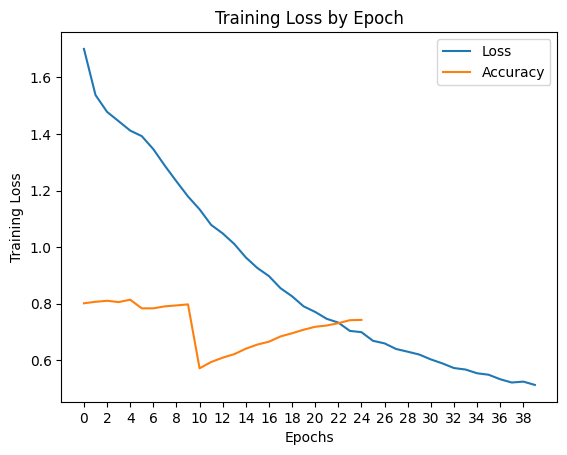

In [175]:
plt.plot(range(len(losses)), losses, label = "Loss")
plt.plot(range(len(accuracies)), accuracies, label = "Accuracy")
plt.legend()
plt.xticks(range(len(losses))[::2])
plt.title("Training Loss by Epoch")
plt.ylabel("Training Loss")
plt.xlabel("Epochs")
plt.savefig("./graphics/CNN_Training_Loss")
plt.show()